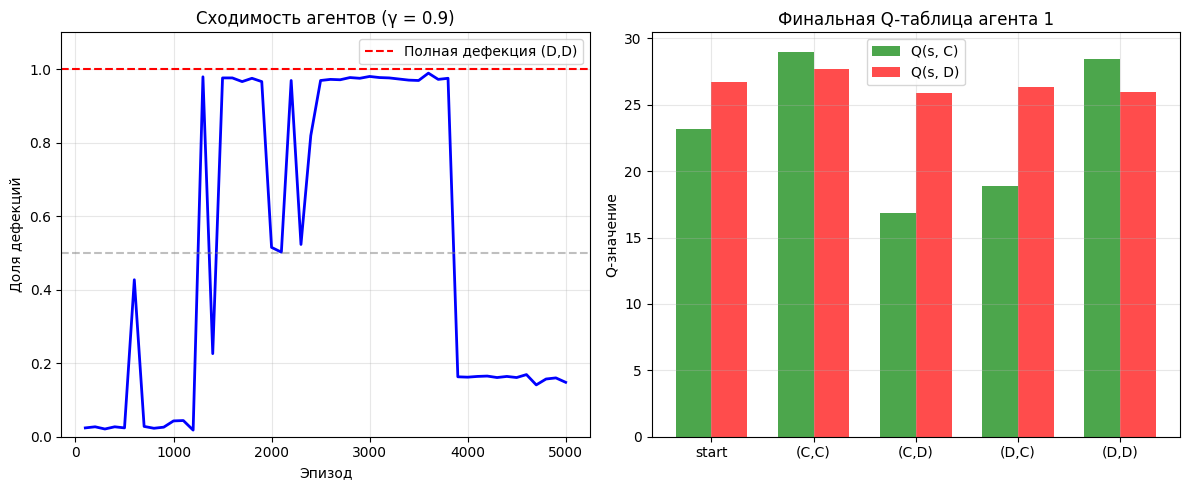

АНАЛИЗ ФИНАЛЬНОГО ПОВЕДЕНИЯ (последние 100 эпизодов)
Доля дефекций в финальных эпизодах: 0.132
Доминирующее действие: C (кооперация)

Теоретическое предсказание:
  Равновесие Нэша: (D, D) — оба агента дефектируют
  Эксперимент: доля дефекций = 0.132
  ✗ Результат расходится с равновесием Нэша

ВАРИАЦИЯ КОЭФФИЦИЕНТА ДИСКОНТИРОВАНИЯ γ
γ = 0.10: доля дефекций = 0.976
γ = 0.30: доля дефекций = 0.980
γ = 0.50: доля дефекций = 0.976
γ = 0.70: доля дефекций = 0.975
γ = 0.80: доля дефекций = 0.978
γ = 0.90: доля дефекций = 0.978
γ = 0.95: доля дефекций = 0.169
γ = 0.99: доля дефекций = 0.974

Критическое γ (переход к кооперации): 0.95


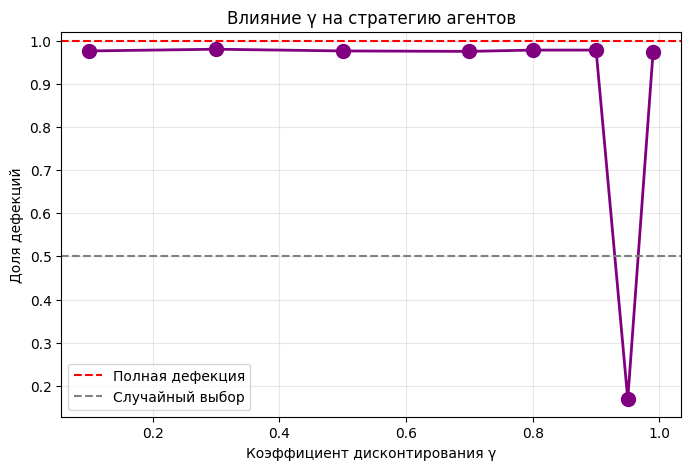

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import warnings
warnings.filterwarnings('ignore')


PAYOFF = np.array([
    [3, 0],
    [5, 1]
])

class QLearningAgent:

    def __init__(self, alpha=0.1, gamma=0.9, epsilon=0.05):
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self._init_q_table()

    #0C 1D
    def _init_q_table(self):
        self.q_table = {
            'start': np.zeros(2),
            (0, 0): np.zeros(2),
            (0, 1): np.zeros(2),
            (1, 0): np.zeros(2),
            (1, 1): np.zeros(2)
        }

    def choose_action(self, state):
        if np.random.random() < self.epsilon:
            return np.random.randint(2)  # 0 или 1 случайно
        else:
            return np.argmax(self.q_table[state])

    def update(self, state, action, reward, next_state):
        """
        Q(s,a) = Q(s,a) + α * [r + γ * max Q(s',a') - Q(s,a)]
        """
        best_next = np.max(self.q_table[next_state])
        td_target = reward + self.gamma * best_next
        td_error = td_target - self.q_table[state][action]
        self.q_table[state][action] += self.alpha * td_error

def run_episode(agent1, agent2, train=True):
    actions_history = []

    state1 = 'start'
    state2 = 'start'

    for step in range(10):
        a1 = agent1.choose_action(state1)
        a2 = agent2.choose_action(state2)

        r1 = PAYOFF[a1][a2]
        r2 = PAYOFF[a2][a1]

        next_state1 = (a1, a2)
        next_state2 = (a2, a1)

        if train:
            agent1.update(state1, a1, r1, next_state1)
            agent2.update(state2, a2, r2, next_state2)

        state1 = next_state1
        state2 = next_state2
        actions_history.append(a1)

    return actions_history

def compute_defection_rate(agent1, agent2, n_episodes=100):
    total_actions = 0
    total_defections = 0
    for _ in range(n_episodes):
        actions = run_episode(agent1, agent2, train=False)
        total_actions += len(actions)
        total_defections += sum(actions)
    return total_defections / total_actions

# Параметры
N_EPISODES = 5000
ALPHA = 0.1
GAMMA = 0.9
EPSILON = 0.05
WINDOW = 100

agent1 = QLearningAgent(alpha=ALPHA, gamma=GAMMA, epsilon=EPSILON)
agent2 = QLearningAgent(alpha=ALPHA, gamma=GAMMA, epsilon=EPSILON)

defection_rates = []

for episode in range(N_EPISODES):
    actions = run_episode(agent1, agent2, train=True)

    if (episode + 1) % WINDOW == 0:
        dr = compute_defection_rate(agent1, agent2, n_episodes=100)
        defection_rates.append(dr)

# ============================================================
# 2.5 Визуализация результатов
# ============================================================
plt.figure(figsize=(12, 5))

# График доли дефекций
plt.subplot(1, 2, 1)
plt.plot(range(WINDOW, N_EPISODES + 1, WINDOW), defection_rates, 'b-', linewidth=2)
plt.axhline(y=1.0, color='r', linestyle='--', label='Полная дефекция (D,D)')
plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
plt.xlabel('Эпизод')
plt.ylabel('Доля дефекций')
plt.title(f'Сходимость агентов (γ = {GAMMA})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0, 1.1)

# Q-таблица первого агента (финальная)
plt.subplot(1, 2, 2)
states = ['start', '(C,C)', '(C,D)', '(D,C)', '(D,D)']
state_keys = ['start', (0,0), (0,1), (1,0), (1,1)]
q_values_C = [agent1.q_table[s][0] for s in state_keys]
q_values_D = [agent1.q_table[s][1] for s in state_keys]

x = np.arange(len(states))
width = 0.35
plt.bar(x - width/2, q_values_C, width, label='Q(s, C)', color='green', alpha=0.7)
plt.bar(x + width/2, q_values_D, width, label='Q(s, D)', color='red', alpha=0.7)
plt.xticks(x, states)
plt.ylabel('Q-значение')
plt.title('Финальная Q-таблица агента 1')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================
# 2.6 Анализ установившейся стратегии
# ============================================================
print("=" * 50)
print("АНАЛИЗ ФИНАЛЬНОГО ПОВЕДЕНИЯ (последние 100 эпизодов)")
print("=" * 50)

final_actions = []
for _ in range(100):
    actions = run_episode(agent1, agent2, train=False)
    final_actions.extend(actions)

final_defection_rate = sum(final_actions) / len(final_actions)
print(f"Доля дефекций в финальных эпизодах: {final_defection_rate:.3f}")
print(f"Доминирующее действие: {'D (дефекция)' if final_defection_rate > 0.5 else 'C (кооперация)'}")

# Равновесие Нэша
print("\nТеоретическое предсказание:")
print("  Равновесие Нэша: (D, D) — оба агента дефектируют")
print(f"  Эксперимент: доля дефекций = {final_defection_rate:.3f}")
if final_defection_rate > 0.9:
    print("  ✓ Результат совпадает с равновесием Нэша")
else:
    print("  ✗ Результат расходится с равновесием Нэша")

# ============================================================
# 2.7 Эксперимент с вариацией gamma
# ============================================================
print("\n" + "=" * 50)
print("ВАРИАЦИЯ КОЭФФИЦИЕНТА ДИСКОНТИРОВАНИЯ γ")
print("=" * 50)

gamma_values = [0.1, 0.3, 0.5, 0.7, 0.8, 0.9, 0.95, 0.99]
final_rates = []

for gamma in gamma_values:
    a1 = QLearningAgent(alpha=ALPHA, gamma=gamma, epsilon=EPSILON)
    a2 = QLearningAgent(alpha=ALPHA, gamma=gamma, epsilon=EPSILON)

    # Обучение
    for ep in range(N_EPISODES):
        run_episode(a1, a2, train=True)

    # Оценка финальной стратегии
    actions = []
    for _ in range(100):
        actions.extend(run_episode(a1, a2, train=False))

    dr = sum(actions) / len(actions)
    final_rates.append(dr)
    print(f"γ = {gamma:.2f}: доля дефекций = {dr:.3f}")

print(f"\nКритическое γ (переход к кооперации): ", end="")
critical_found = False
for g, dr in zip(gamma_values, final_rates):
    if dr < 0.9:
        print(f"{g:.2f}")
        critical_found = True
        break
if not critical_found:
    print("не найдено (всегда дефекция)")

# График зависимости от gamma
plt.figure(figsize=(8, 5))
plt.plot(gamma_values, final_rates, 'o-', color='purple', linewidth=2, markersize=10)
plt.axhline(y=1.0, color='r', linestyle='--', label='Полная дефекция')
plt.axhline(y=0.5, color='gray', linestyle='--', label='Случайный выбор')
plt.xlabel('Коэффициент дисконтирования γ')
plt.ylabel('Доля дефекций')
plt.title('Влияние γ на стратегию агентов')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()